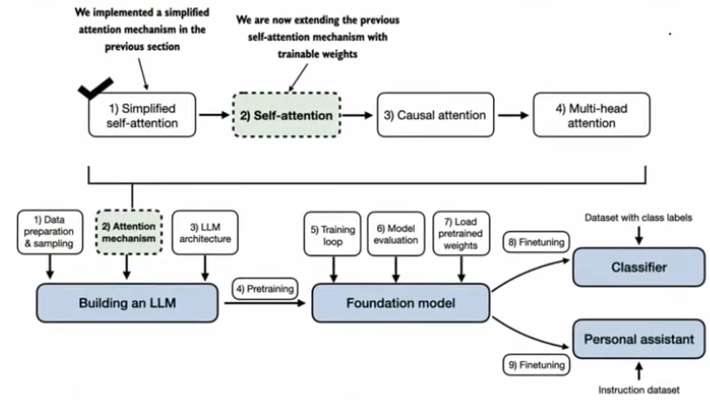

In [1]:
from IPython.display import Image
Image("images/stage1_8_attn_stages.png", width=800)

### Implenting CAUSAL Attention

#### Hiding future words with Causal Attention

- Reuse the QUERY and KEY weight matrices of the SelfAttention_v2 object from Self Attention stage

In [4]:
import torch
import torch.nn as nn

class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, inputs):
        keys = self.W_key(inputs)
        queries = self.W_query(inputs)
        values = self.W_value(inputs)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / (keys.shape[-1] ** 0.5), dim=-1)
        context_vectors = attn_weights @ values

        return context_vectors

In [6]:
torch.manual_seed(789)

inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # your     x^1
     [0.55, 0.87, 0.66], # journey  x^2
     [0.57, 0.85, 0.64], # starts   x^3
     [0.22, 0.58, 0.33], # with     x^4
     [0.77, 0.25, 0.10], # one      x^5
     [0.05, 0.80, 0.55]] # step     x^6
)

d_in = inputs.shape[1]
d_out = 2

sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


In [7]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
values = sa_v2.W_value(inputs)

attn_scores = queries @ keys.T

attn_weights = torch.softmax(attn_scores / (keys.shape[-1] ** 0.5), dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


#### Causal attention masking

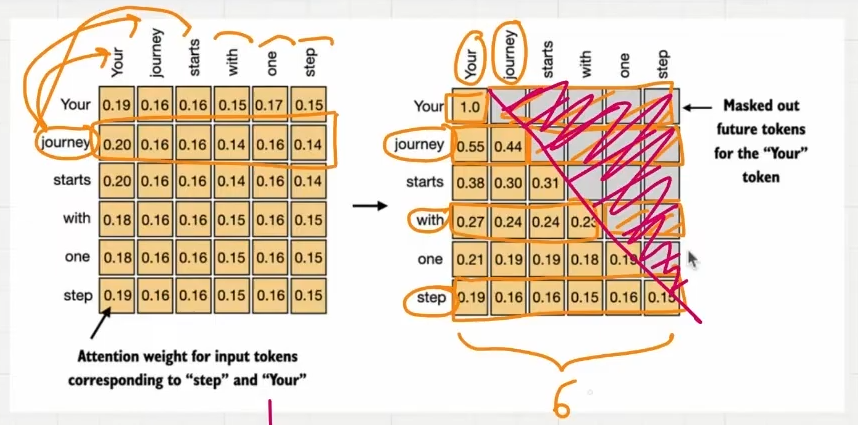

In [30]:
Image("images/stage1_8_causal_attn_mask.png", width=500)


We can now use Pytorch's tril function to create a mask where the values above the diagonal are zero

- tril -> lower triangular matrix

In [8]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


Now, we can multiply this mask with the attention weights to zero out the values above the diagonal

In [9]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


Elements above diagonal are zeroed out

Next step, is to renormalize the attention weights to sum up to 1 again in each row.

We can achieve this by dividing each element in each row by sum of each row

In [10]:
row_sums = masked_simple.sum(dim=1, keepdim=True)
maskedsimple_norm = masked_simple / row_sums
print(maskedsimple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


The result is an attention weight matrix where the attention weights above the diagonal are zeroed out 

But, there is a big problem of DATA LEAKAGE, how ??

We are doing normalization after attention score calculation which means the score has components of other tokens as well.



Instead of making them ZERO directly and then normalizing, if we add -INFINITY to upper diagonal elements

And, then doing the softmax normalization, it will result to ZERO (exp(-inf) = 0)

In [11]:
print(attn_scores)

tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)


In [16]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)

print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


Now, all we need is to apply softmax function to these results 

In [17]:
keys.shape[-1]


2

In [ ]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1) 
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


We could now use modified attention weights to compute context vectors via 

context_vec = attn_weights @ values

### MASKING Additional ATTENTION WEIGHTS with DROPOUT

In the following code we will use a dropout rate of 50%, which means masking out half of the attention weights.

When we will train GPT, we will reduce the dropout to 0.1 or 0.2 (10 or 20%)

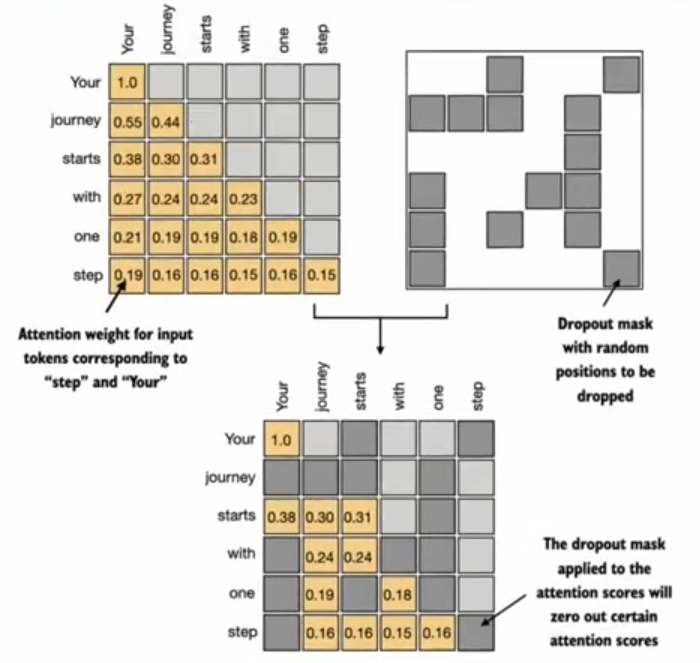

In [21]:
Image("images/stage1_8_dropout.png", width=500)


In [19]:
torch.manual_seed(123)

dropout = torch.nn.Dropout(0.5)
example = torch.ones(6, 6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


When applying dropout to an attention weight matrix with a rate of 50%, half of the elements in the matrix are randomly set to ZERO.

To compensate for reduction in active elements, the values of the remaining elemnets in the matrix are scaled up by a factor of 1/0.5 = 2

This scaling is crucial to maintain the overall balance of the attention weights, ensuring that the average influence of the attention mechanism remains consistent during both the training and inference phase.

In [22]:
# Let's apply the dropout to the attention weights matrix 

torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
print(dropout(attn_weights))



tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


The resulting attention weight matrix now has additional elements ZEROED out and remaining one SCALED by 2

### IMPLEMENTING PYTHON CLASS FOR CAUSAL ATTENTION

STEPS:

INPUT -> KEY, QUERY, VALUE -> QUERY * KEY.T -> Attention Score -> ZEROING UPPER DIAGONAL -> SCALING BY SQRT(0.5) + DROPOUT + SOFTMAX -> ATTENTION WEIGHTS * VALUE -> CONTEXT VECTOR

We will ensure our code can handle batches consisting of more than one input

This will ensure our CausalAttention class supports batch outputs produced by Data Loader

Let's start with 2 inputs with 6 tokens and each token has embedding dimension 3

In [23]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


This results in 3D tensor consisting of 2 input texts with 6 tokens each, where each token is 3dim embedding vector

The following CausalAttention class is similar to SelfAttention, except that we now added the dropout AND CAUSAL MASK components

In [24]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out 
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)    

        # calculate attention scores
        attn_scores = queries @ keys.transpose(1,2)

        # mask the attention scores to prevent attending to future tokens
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        
        # calculate attention weights
        attn_weights = torch.softmax(attn_scores / (keys.shape[-1] ** 0.5), dim=-1)

        # apply dropout to attention weights
        attn_weights = self.dropout(attn_weights)

        # calculate context vectors as weighted sum of values
        context_vectors = attn_weights @ values
        
        return context_vectors

Use of "register buffer" is not strictly necessary for all use cases

When we use CausalAttention class in our LLM, buffers are automatically moved to appropriate device (CPU or GPU) along with our model, which will be relevant in training LLM in future

We don't need to manually ensure that, these tensors are on same device as model parameters, avoiding device mismath errors.

In [26]:
print(d_in, d_out, batch.shape[1], 0.5)

3 2 6 0.5


In [27]:
torch.manual_seed(123)
context_length = batch.shape[1]
causal_attn = CausalAttention(d_in, d_out, context_length, dropout=0.0)
context_vecs = causal_attn(batch)

print(context_vecs.shape)

torch.Size([2, 6, 2])


In [28]:
print(context_vecs)

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)
